# Robot Diffusion Policy: A Minimal Tutorial Driven by Real Questions

This tutorial is organized around several questions that commonly cause confusion when learning robot Diffusion Policy.

The first half focuses on the core mechanism:

1. What is the “data” generated by diffusion in robotics?
2. What does the noise actually look like?
3. What are the model input and supervision target during training?
4. Does the network predict the cumulative noise from $A_0$ to $A_k$?
5. If cumulative noise can be used to recover $A_0$, why is recursive sampling still necessary?
6. What exactly happens at each step of recursive sampling?
7. Why can training directly use an arbitrary $A_k$ to learn denoising without unrolling the complete recursive process?

The second half does not repeat these explanations. Instead, it uses a minimal demo to verify the conclusions above and explains how an action chunk is executed on a real robot.


## A One-Sentence Overview

The basic workflow of Diffusion Policy is:

```text
Current observation and task condition
        ↓
Generate a random action sequence
        ↓
Repeatedly revise the sequence according to the condition
        ↓
Obtain an action trajectory resembling expert demonstrations
        ↓
Execute only the first few steps
        ↓
Observe again and generate a new sequence
```

Therefore, it does not directly answer:

> Where should the robot move in the next step?

Instead, it answers:

> Under the current condition, what might an entire reasonable action trajectory look like?


In [33]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# Question 1: What Exactly Is the “Data” in Robot Diffusion?

In image diffusion, the model generates an image.

In robot Diffusion Policy, the model generates a sequence of actions:

$$
A_0=(a_t,a_{t+1},\ldots,a_{t+H-1})
$$

This sequence is called an **action chunk**.

For an intuitive example, assume that each robot action is a two-dimensional position:

$$
a_t=(x_t,y_t)
$$

An action chunk of length 32 is therefore a two-dimensional trajectory:

$$
A_0\in\mathbb{R}^{32\times 2}
$$


A0 shape: (32, 2)
First five rows:
tensor([[0.0000, 0.0000],
        [0.0323, 0.0354],
        [0.0645, 0.0705],
        [0.0968, 0.1048],
        [0.1290, 0.1380]])


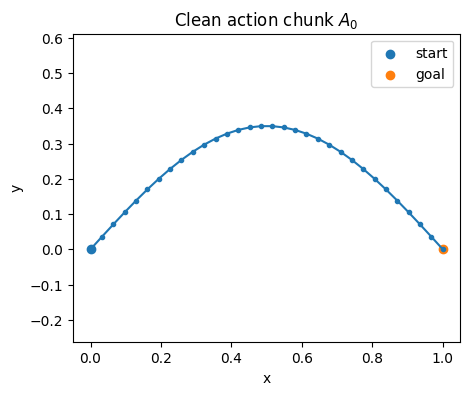

In [34]:
def make_trajectory(horizon=32):
    t = torch.linspace(0, 1, horizon)
    x = t
    y = 0.35 * torch.sin(math.pi * t)
    return torch.stack([x, y], dim=-1)

A0 = make_trajectory()

print("A0 shape:", tuple(A0.shape))
print("First five rows:")
print(A0[:5])

plt.figure(figsize=(5, 4))
plt.plot(A0[:, 0], A0[:, 1], marker="o", markersize=3)
plt.scatter(A0[0, 0], A0[0, 1], label="start")
plt.scatter(A0[-1, 0], A0[-1, 1], label="goal")
plt.title("Clean action chunk $A_0$")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

## Why Does Diffusion Policy Usually Generate an Action Chunk Instead of a Single Action?

A single-step policy learns:

$$
p(a_t\mid O_t)
$$

An action-chunk policy instead models the joint distribution of an entire sequence:

$$
p(a_t,a_{t+1},\ldots,a_{t+H-1}\mid O_t)
$$

There are three main reasons for generating an action chunk.

First, robot actions have continuous temporal structure. For example, “raise the arm, approach the target, adjust the pose, and close the gripper” is not a collection of independent actions, but a locally coordinated process. Jointly generating the whole sequence allows the model to directly learn continuity and phase relationships among actions.

Second, robot policies are often multimodal. The same target may be approached from either the left or the right. Such multimodality usually appears at the trajectory level rather than in an isolated action. Generating an action chunk makes it easier to select one coherent trajectory mode and avoids averaging several strategies into an unnatural compromise.

Third, diffusion sampling requires multiple network forward passes. If a complete recursive denoising process produced only one action, the computational cost would be high. Generating multiple actions at once amortizes one diffusion inference across several control steps.

Therefore, the role of an action chunk is:

> To jointly model temporal continuity, multimodal trajectory structure, and to reduce the cost of running diffusion sampling at every control step.

However, the predicted action chunk is usually not executed fully in open loop. The robot typically executes only the first few actions, observes the environment again, and generates a new action chunk to maintain closed-loop feedback.


### The Most Important Point in This Section

The object generated by Diffusion Policy is not a single action $a_t$, but an entire action chunk $A_0$.

Therefore, diffusion learns more than “where to move from the current position.” It also learns:

- the overall direction of the trajectory;
- continuity between actions;
- acceleration, deceleration, and turning patterns;
- local coordination among multiple action phases.


# Question 2: What Does the Noise Actually Look Like?

The noise has exactly the same shape as the action chunk.

If:

$$
A_0\in\mathbb{R}^{32\times 2}
$$

then:

$$
\epsilon\in\mathbb{R}^{32\times 2}
$$

Every time step and every action dimension has a corresponding Gaussian random value:

$$
\epsilon_{i,j}\sim\mathcal{N}(0,1)
$$

Thus, “pure noise” in robotics can be understood as a random action table, or as a completely disordered random trajectory.


noise shape: (32, 2)
First five rows:
tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487]])


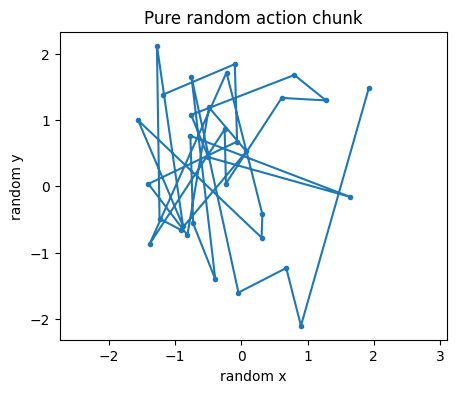

In [35]:
noise = torch.randn_like(A0)

print("noise shape:", tuple(noise.shape))
print("First five rows:")
print(noise[:5])

plt.figure(figsize=(5, 4))
plt.plot(noise[:, 0], noise[:, 1], marker="o", markersize=3)
plt.title("Pure random action chunk")
plt.xlabel("random x")
plt.ylabel("random y")
plt.axis("equal")
plt.show()

This random trajectory is not sent directly to the robot for execution.

It is only the initial state of the generation process:

```text
Random action draft
    ↓
Repeated revisions
    ↓
Reasonable action trajectory
```


## Question 3: What Are the Model Input and Target During Training?

Before discussing training, distinguish among three objects:

* $A_0$: a clean action trajectory from an expert demonstration;
* $A_k$: the trajectory obtained after adding a certain amount of noise to $A_0$;
* $k$: the current amount of noise, namely the noise level.

The model also receives the task condition $O$. On a real robot, $O$ may include camera images, robot joint states, end-effector poses, or language instructions.

Training first takes a real action trajectory from the demonstration data:

$$
A_0
$$

It then randomly chooses a noise level:

$$
k\sim\operatorname{Uniform}{0,\ldots,K-1}
$$

Next, it samples Gaussian noise with the same shape as the action trajectory:

$$
\epsilon\sim\mathcal{N}(0,I)
$$

The following equation corrupts the clean action $A_0$ into the noisy action $A_k$:

$$
A_k
=
\sqrt{\bar{\alpha}_k}A_0
+
\sqrt{1-\bar{\alpha}_k}\epsilon
$$

Here, $\bar{\alpha}_k$ determines how much of the original action information remains at noise level $k$:

* when $k$ is small, $A_k$ remains close to $A_0$;
* when $k$ is large, $A_k$ gradually approaches a purely random action sequence.

Therefore, the actual network input during training is:

$$
(A_k,k,O)
$$

That is:

* the current noisy action;
* the current noise level;
* the current task and robot state.

The network predicts the noise used to generate $A_k$:

$$
\hat{\epsilon}
=
\epsilon_\theta(A_k,k,O)
$$

The training loss is usually:

$$
\mathcal{L}
=
\left\|
\epsilon-\hat{\epsilon}
\right\|^2
$$

A particularly important distinction is:

* $A_0$ is the original expert action and the source of the training example;
* under standard $\epsilon$-prediction, however, the direct supervision target is not $A_0$, but the noise $\epsilon$.

More precisely, one training example is constructed as:

$$
A_0
\xrightarrow[\epsilon]{\text{add noise at level }k}
A_k
$$

The network then learns:

$$
(A_k,k,O)
\longrightarrow
\epsilon
$$

In other words, the model does not directly recover the expert trajectory from the noisy trajectory. It first learns to identify the noise mixed into it.


In [36]:
steps = 50
betas = torch.linspace(1e-4, 2e-2, steps)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def add_noise(A0, k, noise=None):
    if noise is None:
        noise = torch.randn_like(A0)

    alpha_bar = alpha_bars[k]

    Ak = (
        torch.sqrt(alpha_bar) * A0
        + torch.sqrt(1.0 - alpha_bar) * noise
    )

    return Ak, noise

k_example = 30
Ak_example, epsilon_example = add_noise(A0, k_example)

print("k =", k_example)
print("A0 shape:", tuple(A0.shape))
print("Ak shape:", tuple(Ak_example.shape))
print("epsilon label shape:", tuple(epsilon_example.shape))

k = 30
A0 shape: (32, 2)
Ak shape: (32, 2)
epsilon label shape: (32, 2)


The standard training relation is:

$$
(A_k,k,O)
\longrightarrow
\hat{\epsilon}
$$

with the loss:

$$
\mathcal{L}
=
\left\|
\epsilon-\hat{\epsilon}
\right\|^2
$$

A useful summary is:

- $A_0$: the expert-action ground truth;
- $A_k$: the noisy action used as part of the network input;
- $k$: the noise level provided to the network;
- $\epsilon$: the supervision label under standard noise prediction.


# Question 4: Must the Model Predict the Cumulative Noise from $A_0$ to $A_k$?

Not necessarily. It depends on the prediction parameterization used by the model.

Under the standard $\epsilon$-prediction used in this tutorial, the forward noising process is:

$$
A_k
=
\sqrt{\bar{\alpha}_k}A_0
+
\sqrt{1-\bar{\alpha}_k}\epsilon
$$

The network learns to predict:

$$
\hat{\epsilon}
=
\epsilon_\theta(A_k,k,O)
$$

Here, $\epsilon$ is not the noise added only at step $k$. It is the **cumulative equivalent noise** obtained by combining the Gaussian perturbations from all preceding steps.

Note that “cumulative equivalent noise” is not a simple sum of the noise at every step. Each step is scaled differently, and the scaled terms jointly form an equivalent random variable that still follows a standard Gaussian distribution. This concept will appear again later.

Therefore, under $\epsilon$-prediction, an $A_k$ at any noise level can be constructed directly from $A_0$ without explicitly computing:

$$
A_0
\rightarrow
A_1
\rightarrow
\cdots
\rightarrow
A_k
$$

However, diffusion models do not have to use $\epsilon$-prediction. Depending on the parameterization, a model may directly predict the clean action:

$$
\hat{A}_0
$$

or predict a variable combining the clean action and noise:

$$
\hat{v}
$$

It may also directly learn the score of the current noisy-action distribution:

$$
\nabla_{A_k}\log p_k(A_k\mid O)
$$

The score points in the direction in which probability density increases most rapidly. Intuitively, it tells the current noisy action:

> In which direction should you move to reach a higher-probability region that more closely resembles expert demonstration actions?

For Gaussian diffusion, noise prediction and score prediction can be converted into each other:

$$
s_\theta(A_k,k,O)
=
-
\frac{
\epsilon_\theta(A_k,k,O)
}{
\sqrt{1-\bar{\alpha}_k}
}
$$

Therefore, predicting $\epsilon$, predicting $A_0$, predicting $v$, and learning the score are not entirely different tasks. They are different output parameterizations of the same denoising process.

This tutorial uses $\epsilon$-prediction. Consequently, the statement that “the model predicts cumulative equivalent noise” applies only to the parameterization used here.

A more accurate conclusion is:

> The $\epsilon$-prediction model used in this tutorial predicts cumulative equivalent noise, but diffusion models do not necessarily use noise as their output target.


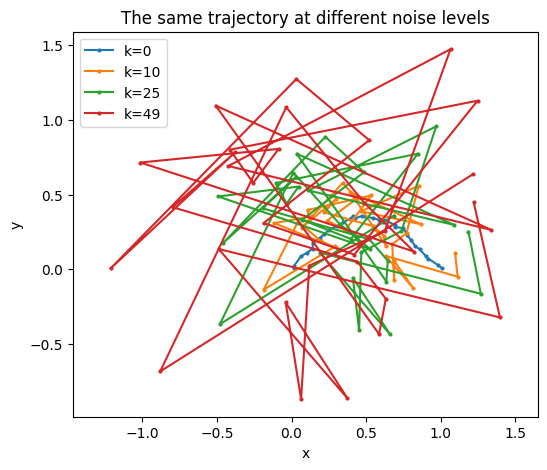

In [37]:
shared_noise = torch.randn_like(A0)

plt.figure(figsize=(6, 5))

for k in [0, 10, 25, 49]:
    Ak, _ = add_noise(A0, k, shared_noise)

    plt.plot(
        Ak[:, 0],
        Ak[:, 1],
        marker="o",
        markersize=2,
        label=f"k={k}",
    )

plt.title("The same trajectory at different noise levels")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

### This Distinction Must Be Stated Precisely

At each call, the network predicts:

> The cumulative equivalent noise in the current $A_k$ relative to the latent clean action $A_0$.

It does not predict:

> The noise corresponding only to the single transition from $A_k$ to $A_{k-1}$.


# Question 5: If Total Noise Allows One-Step Recovery, Why Is Recursion Necessary?

Algebraically, if the true cumulative noise is known, $A_0$ can be recovered in one step:

$$
A_0
=
\frac{
A_k-\sqrt{1-\bar{\alpha}_k}\epsilon
}{
\sqrt{\bar{\alpha}_k}
}
$$

The following code verifies this directly.


Maximum recovery error with true noise: 0.0000000894


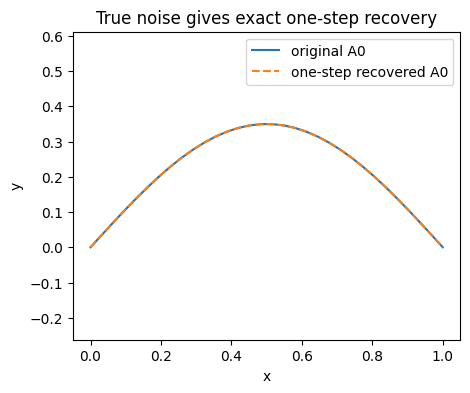

In [38]:
k = steps - 1
Ak, true_noise = add_noise(A0, k)

alpha_bar = alpha_bars[k]

A0_recovered = (
    Ak
    - torch.sqrt(1.0 - alpha_bar) * true_noise
) / torch.sqrt(alpha_bar)

error = (A0_recovered - A0).abs().max().item()

print(f"Maximum recovery error with true noise: {error:.10f}")

plt.figure(figsize=(5, 4))
plt.plot(A0[:, 0], A0[:, 1], label="original A0")
plt.plot(
    A0_recovered[:, 0],
    A0_recovered[:, 1],
    linestyle="--",
    label="one-step recovered A0",
)
plt.title("True noise gives exact one-step recovery")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

Therefore, the formula itself does not prevent one-step recovery.

The real issue is:

> The network does not know the actual random noise used in this noising instance.

For the same $A_k$, multiple different pairs may exist:

$$
(A_0,\epsilon)
$$

The network can only make a statistical estimate from $A_k$, $k$, and condition $O$.

Under mean-squared-error training, the ideal model is closer to:

$$
\epsilon_\theta^*(A_k,k,O)
=
\mathbb{E}[\epsilon\mid A_k,k,O]
$$

It predicts a conditional mean rather than reconstructing an unobservable random history.


## Why Is a One-Step Estimate Especially Unreliable at High Noise Levels?

When $k$ is large:

$$
A_k\approx\epsilon
$$

The action signal is already weak.

The first input observed by the network is almost a purely random trajectory. It can make only coarse judgments, such as:

- whether the trajectory should generally move left or right;
- whether it should pass above or below;
- which broad direction it should follow.

Recovering the precise action at every time step in a single pass is difficult.


# Question 6: What Does Recursive Sampling Actually Do?

Recursive sampling is not:

```text
Predict the noise added only at step k,
subtract it,
then predict the noise added only at step k-1
```

A more accurate description is:

```text
Current Ak
  ↓
Re-estimate the cumulative noise in the current state
  ↓
Obtain the current estimate of the final A0
  ↓
Construct a slightly cleaner Ak-1
  ↓
Estimate again at Ak-1
```

Formally:

$$
A_k
\rightarrow
\hat{\epsilon}_k
\rightarrow
\hat{A}_0^{(k)}
\rightarrow
A_{k-1}
$$

Then:

$$
A_{k-1}
\rightarrow
\hat{\epsilon}_{k-1}
\rightarrow
\hat{A}_0^{(k-1)}
\rightarrow
A_{k-2}
$$

Eventually:

$$
A_K\rightarrow A_{K-1}\rightarrow\cdots\rightarrow A_0
$$


### The Most Intuitive Analogy

Think of pure noise as a roughly scribbled draft of a robot trajectory.

First revision:

> It should probably move to the right.

Second revision:

> It should probably go around from above.

Third revision:

> The trajectory should be smoother, and the final steps should align with the target.

Every revision attempts to recover the final trajectory, but each later revision starts from a clearer intermediate draft.


## Question 7: If Training Uses Only One Random Noise Level at a Time, Why Can Inference Generate Actions Recursively?

In the training procedure above, each expert action trajectory is paired with only one randomly selected noise level $k$ per iteration.

For example, one iteration may use a highly noisy action $A_{37}$, while another may use a less noisy action $A_{12}$.

The model does not traverse the complete denoising process within a single training example:

$$
A_K
\rightarrow
A_{K-1}
\rightarrow
\cdots
\rightarrow
A_0
$$

This raises a new question:

> If training exposes the model to only one random noise level at a time, why can inference repeatedly call the same model and gradually turn pure noise into an action trajectory?

This differs from the earlier question, “Why can the model not recover $A_0$ in one step?”

The earlier question asks:

> Why is one prediction of cumulative noise at the highest noise level insufficient to obtain a reliable $A_0$ directly?

The present question asks:

> If the complete recursive process is not unrolled during training, why does the model nevertheless learn all the correction rules required for recursive denoising?

### The Training Objective Is Not to Memorize a Fixed Denoising Chain

During training, the model learns the function:

$$
\epsilon_\theta(A_k,k,O)
$$

It receives:

* the current noisy action $A_k$;
* the current noise level $k$;
* the current observation or task condition $O$;

and predicts the cumulative equivalent noise in the current action.

Different training iterations randomly sample different noise levels:

$$
k=4,\ 37,\ 12,\ 49,\ldots
$$

After many iterations, training gradually covers states ranging from low to high noise.

Therefore, the model does not learn one fixed trajectory:

$$
A_K\rightarrow A_{K-1}\rightarrow\cdots\rightarrow A_0
$$

Instead, it learns:

> For an arbitrary noise level and current action state, in which direction should the action be corrected?

### The Model Learns a Conditional Vector Field in Action Space

Each noisy action $A_k$ can be regarded as a point in action space.

The network's noise prediction can be converted into a correction direction:

$$
v_\theta(A_k,k,O)
$$

This vector tells the current action:

> At noise level $k$ and under condition $O$, in which direction should you move to become closer to the distribution of reasonable expert actions?

Defining such a direction at many locations in action space produces a **conditional vector field** that varies with the noise level and task condition:

$$
(A_k,k,O)
\longmapsto
v_\theta(A_k,k,O)
$$

Every randomly sampled $A_k$ during training is effectively a sampled location in this vector field, and the model learns the correct direction at that location.

Through extensive random sampling, the model gradually learns the direction distribution over the action space.

### Inference Repeatedly Moves Through This Vector Field

Robot inference begins from a purely random action:

$$
A_K\sim\mathcal{N}(0,I)
$$

At $A_K$, the network provides a correction direction and uses it to obtain a slightly more reasonable action:

$$
A_K\rightarrow A_{K-1}
$$

After arriving at the new state $A_{K-1}$, the direction predicted earlier at $A_K$ can no longer simply be reused.

The model must compute a new vector at the current location:

$$
v_\theta(A_{K-1},K-1,O)
$$

It then continues:

$$
A_{K-1}\rightarrow A_{K-2}
$$

Repeating this process gives:

$$
A_K
\rightarrow
A_{K-1}
\rightarrow
A_{K-2}
\rightarrow
\cdots
\rightarrow
A_0
$$

Thus, recursive sampling can be understood as:

> Select an initial point from Gaussian noise, then move step by step along the learned conditional vector field until reaching the vicinity of the expert action distribution.

---


### Why Can Training Directly Use $A_k$ and $A_0$ Without Learning Every Denoising Transition Sequentially?

During training, the clean expert action $A_0$ is available. We can therefore sample noise $\epsilon$ and directly construct an action at any noise level:

$$
A_k
=
\sqrt{\bar{\alpha}_k}A_0
+
\sqrt{1-\bar{\alpha}_k}\epsilon
$$

Because $A_0$, $A_k$, and $\epsilon$ are all known, the training procedure can directly tell the model:

> When the input is this $A_k$ at noise level $k$, its corresponding cumulative equivalent noise is $\epsilon$.

The model therefore learns:

$$
(A_k,k,O)
\longrightarrow
\hat{\epsilon}_k
$$

At first glance, this may appear to directly teach recovery of $A_0$ from $A_k$, because the predicted noise gives:

$$
\hat{A}_0
=
\frac{
A_k-\sqrt{1-\bar{\alpha}_k}\hat{\epsilon}_k
}{
\sqrt{\bar{\alpha}_k}
}
$$

However, an important qualification is:

> The model does not learn a deterministic $A_k\rightarrow A_0$ mapping, nor does it actually perform generation from step $k$ to step $0$ during training.

The reason is that $A_k$ and condition $O$ generally do not uniquely determine the original $A_0$. The same noisy action may be produced by different clean actions combined with different noise.

Under a mean-squared-error loss, the model tends to learn:

$$
\epsilon_\theta^*(A_k,k,O)
=
\mathbb{E}
\left[
\epsilon\mid A_k,k,O
\right]
$$

That is, it learns the conditional expectation of cumulative noise in the current noisy state.

This prediction can be converted into a current estimate of $A_0$, but it is not a deterministic recovery of the actual $A_0$. Especially at high noise levels, the one-step estimate $\hat{A}_0$ is often only coarse.

Therefore, $A_0$ serves three purposes during training:

1. constructing $A_k$ at an arbitrary noise level;
2. obtaining the exact supervision label $\epsilon$;
3. learning the conditional denoising direction at every noise level.

Training does not directly teach:

$$
A_k
\rightarrow
A_0
$$

Instead, it supervises a local vector field at different locations and noise levels in action space:

$$
(A_k,k,O)
\longmapsto
v_\theta(A_k,k,O)
$$

Only during inference does the model start from pure noise and repeatedly query this vector field:

$$
A_K
\rightarrow
A_{K-1}
\rightarrow
\cdots
\rightarrow
A_0
$$

A more accurate conclusion is:

> Training can directly use $A_k$ and $A_0$ because the known clean data $A_0$ allows exact denoising supervision to be constructed at any noise level. The model, however, does not learn a one-shot mapping from $A_k$ to the actual $A_0$. It learns a conditional denoising vector field across noise levels, and recursive generation continuously applies these local denoising rules during inference.


# Minimal Demo: Verifying the Mechanism in Code

We now construct a two-dimensional robot task:

- the robot starts at the origin;
- the target is either on the left or on the right;
- for the same target, the robot may pass either above or below.

Therefore, the conditional policy distribution $p(A_0\mid O)$ contains two trajectory modes.

Rather than repeating the theory, this demo verifies three points:

1. how training implements $(A_k,k,O)\rightarrow\epsilon$;
2. how inference recursively queries the denoising vector field;
3. whether different initial noise samples can produce different modes of a multimodal policy.


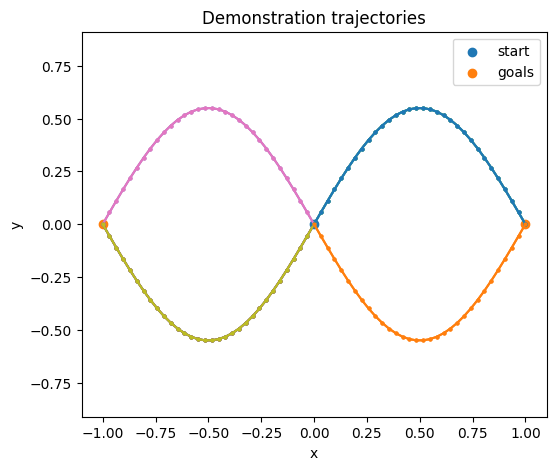

In [39]:
def generate_batch(batch_size, horizon=32):
    target_id = torch.randint(0, 2, (batch_size,))

    mode = torch.where(
        torch.rand(batch_size) > 0.5,
        torch.ones(batch_size),
        -torch.ones(batch_size),
    )

    t = torch.linspace(0, 1, horizon)
    t = t.unsqueeze(0).repeat(batch_size, 1)

    target_x = torch.where(
        target_id == 0,
        -torch.ones(batch_size),
        torch.ones(batch_size),
    )

    x = target_x.unsqueeze(1) * t
    y = 0.55 * mode.unsqueeze(1) * torch.sin(math.pi * t)

    trajectories = torch.stack([x, y], dim=-1)
    conditions = F.one_hot(target_id, num_classes=2).float()

    return trajectories, conditions

demo, condition = generate_batch(12)

plt.figure(figsize=(6, 5))

for traj in demo:
    plt.plot(
        traj[:, 0],
        traj[:, 1],
        marker="o",
        markersize=2,
    )

plt.scatter([0], [0], label="start")
plt.scatter([-1, 1], [0, 0], label="goals")
plt.title("Demonstration trajectories")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

Here, the condition $O$ is simplified to:

$$
O=
\begin{cases}
(1,0), & \text{left target}\\
(0,1), & \text{right target}
\end{cases}
$$

The condition used by a real Diffusion Policy may include:

- the current image;
- several recent image frames;
- joint states;
- the end-effector pose;
- a language instruction.


In [40]:
def timestep_embedding(k, dim=32):
    half = dim // 2

    frequencies = torch.exp(
        -math.log(10000.0)
        * torch.arange(half, device=k.device)
        / max(half - 1, 1)
    )

    angles = k.float().unsqueeze(1) * frequencies.unsqueeze(0)

    return torch.cat(
        [torch.sin(angles), torch.cos(angles)],
        dim=1,
    )


class TinyDiffusionPolicy(nn.Module):
    def __init__(self, horizon=32):
        super().__init__()

        flat_dim = horizon * 2

        self.net = nn.Sequential(
            nn.Linear(flat_dim + 32 + 2, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, flat_dim),
        )

    def forward(self, Ak, k, condition):
        batch_size = Ak.shape[0]

        x = torch.cat(
            [
                Ak.reshape(batch_size, -1),
                timestep_embedding(k),
                condition,
            ],
            dim=1,
        )

        return self.net(x).reshape_as(Ak)


model = TinyDiffusionPolicy().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)

## 1. Training: Implementing the Noise-Prediction Objective in Code

The following training loop directly implements:

$$
(A_k,k,O)
\longrightarrow
\hat{\epsilon}
$$

The code comments explicitly mark $A_0$, $k$, $\epsilon$, $A_k$, and the noise-prediction loss.


step= 200, recent loss=0.1910
step= 400, recent loss=0.1505
step= 600, recent loss=0.1421
step= 800, recent loss=0.1280
step=1000, recent loss=0.1199
step=1200, recent loss=0.1161
step=1400, recent loss=0.1089
step=1600, recent loss=0.1056
step=1800, recent loss=0.1028
step=2000, recent loss=0.1014
step=2200, recent loss=0.0953
step=2400, recent loss=0.0973
step=2600, recent loss=0.0956
step=2800, recent loss=0.0915
step=3000, recent loss=0.0891


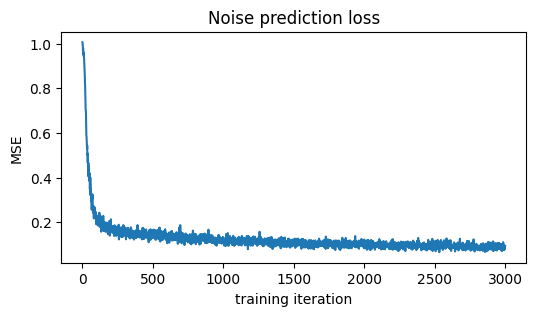

In [41]:
def extract(values, k, target_ndim):
    out = values.to(k.device)[k]

    while out.ndim < target_ndim:
        out = out.unsqueeze(-1)

    return out


losses = []

for step in range(3000):
    # 1. Expert action A0 and task condition O
    A0_batch, condition = generate_batch(256)
    A0_batch = A0_batch.to(device)
    condition = condition.to(device)

    # 2. Randomly sample one noise level k for each trajectory
    k = torch.randint(0, steps, (256,), device=device)

    # 3. Cumulative equivalent noise epsilon
    epsilon = torch.randn_like(A0_batch)

    # 4. Construct Ak directly
    alpha_bar = extract(alpha_bars, k, A0_batch.ndim)

    Ak = (
        torch.sqrt(alpha_bar) * A0_batch
        + torch.sqrt(1.0 - alpha_bar) * epsilon
    )

    # 5. The network predicts cumulative noise
    pred_epsilon = model(Ak, k, condition)

    loss = F.mse_loss(pred_epsilon, epsilon)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (step + 1) % 200 == 0:
        print(
            f"step={step + 1:4d}, "
            f"recent loss={np.mean(losses[-100:]):.4f}"
        )

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title("Noise prediction loss")
plt.xlabel("training iteration")
plt.ylabel("MSE")
plt.show()

## 2. Inference: Recursively Querying the Denoising Direction at the Current State

The following `for` loop corresponds to recursive sampling:

$$
A_K
\rightarrow
A_{K-1}
\rightarrow
\cdots
\rightarrow
A_0
$$

Every time a new intermediate state $A_k$ is obtained, the model recomputes the cumulative-noise estimate at the current location instead of reusing the first prediction.


In [42]:
@torch.no_grad()
def sample(model, condition, horizon=32):
    model.eval()

    condition = condition.to(device)
    batch_size = condition.shape[0]

    # Start from purely random actions
    Ak = torch.randn(
        batch_size,
        horizon,
        2,
        device=device,
    )

    betas_d = betas.to(device)
    alphas_d = alphas.to(device)
    alpha_bars_d = alpha_bars.to(device)

    history = [Ak.cpu()]

    for k_value in reversed(range(steps)):
        k = torch.full(
            (batch_size,),
            k_value,
            device=device,
            dtype=torch.long,
        )

        # Re-estimate cumulative noise at the current Ak
        pred_epsilon = model(Ak, k, condition)

        beta_k = betas_d[k_value]
        alpha_k = alphas_d[k_value]
        alpha_bar_k = alpha_bars_d[k_value]

        reverse_mean = (
            Ak
            - beta_k
            / torch.sqrt(1.0 - alpha_bar_k)
            * pred_epsilon
        ) / torch.sqrt(alpha_k)

        if k_value > 0:
            alpha_bar_prev = alpha_bars_d[k_value - 1]

            posterior_variance = (
                beta_k
                * (1.0 - alpha_bar_prev)
                / (1.0 - alpha_bar_k)
            )

            Ak = (
                reverse_mean
                + torch.sqrt(posterior_variance)
                * torch.randn_like(Ak)
            )
        else:
            Ak = reverse_mean

        history.append(Ak.cpu())

    return Ak.cpu(), history

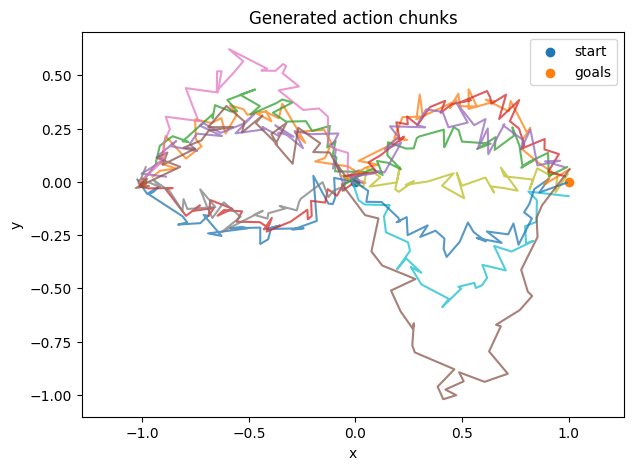

In [43]:
left_condition = torch.tensor([[1.0, 0.0]]).repeat(8, 1)
right_condition = torch.tensor([[0.0, 1.0]]).repeat(8, 1)

left_samples, _ = sample(model, left_condition)
right_samples, _ = sample(model, right_condition)

plt.figure(figsize=(7, 5))

for traj in left_samples:
    plt.plot(traj[:, 0], traj[:, 1], alpha=0.75)

for traj in right_samples:
    plt.plot(traj[:, 0], traj[:, 1], alpha=0.75)

plt.scatter([0], [0], label="start")
plt.scatter([-1, 1], [0, 0], label="goals")
plt.title("Generated action chunks")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

## 3. Result: The Model Learns a Multimodal Policy Distribution

The same target has demonstration trajectories passing both above and below it. Therefore:

$$
p(A_0\mid O)
$$

is a multimodal policy distribution.

If both trajectory modes appear among the generated samples, the model has not simply averaged them into one compromise trajectory. Instead, different initial noise samples can produce different policy modes.


## 4. Visualization: How a Trajectory Gradually Emerges from Noise

The following figure displays several intermediate states from the same sampling run.

Focus on how the trajectory structure changes:

1. the initial state resembles random actions;
2. intermediate states gradually develop a target direction and path mode;
3. later states become smoother and approach the demonstration distribution.


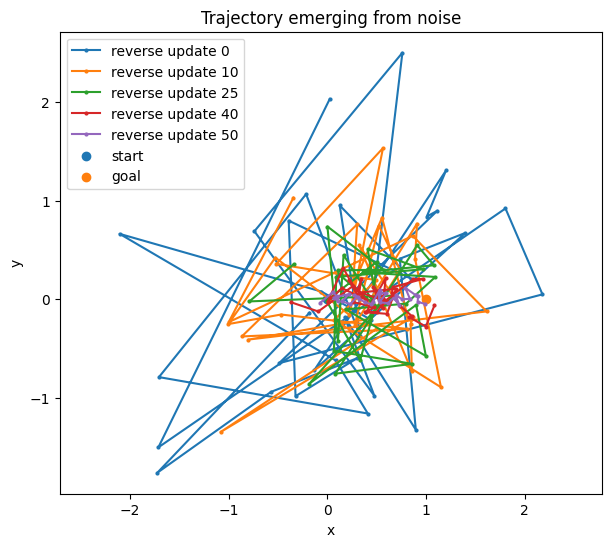

In [44]:
condition = torch.tensor([[0.0, 1.0]])

final_traj, history = sample(model, condition)

plt.figure(figsize=(7, 6))

for index in [0, 10, 25, 40, 50]:
    traj = history[index][0]

    plt.plot(
        traj[:, 0],
        traj[:, 1],
        marker="o",
        markersize=2,
        label=f"reverse update {index}",
    )

plt.scatter([0], [0], label="start")
plt.scatter([1], [0], label="goal")
plt.title("Trajectory emerging from noise")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

## 5. Experimental Verification: One-Step Estimation Versus Recursive Sampling

Question 5 showed that if the true cumulative noise is known, $A_0$ can be recovered in one step. At the highest noise level, however, the model can provide only a statistical estimate.

The following comparison is retained:

- dashed lines: $\hat{A}_0$ computed once from the highest-noise state;
- solid lines: recursively sampled trajectories based on continuously updated intermediate states.

This experiment verifies the preceding conclusion without repeating the theoretical derivation.


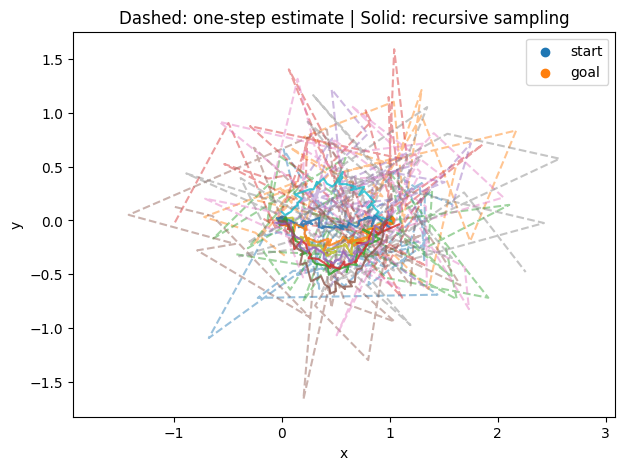

In [45]:
@torch.no_grad()
def one_step_x0_estimate(model, condition, horizon=32):
    model.eval()

    condition = condition.to(device)
    batch_size = condition.shape[0]

    k_value = steps - 1

    Ak = torch.randn(
        batch_size,
        horizon,
        2,
        device=device,
    )

    k = torch.full(
        (batch_size,),
        k_value,
        device=device,
        dtype=torch.long,
    )

    pred_epsilon = model(Ak, k, condition)

    alpha_bar = alpha_bars[k_value].to(device)

    x0_hat = (
        Ak
        - torch.sqrt(1.0 - alpha_bar) * pred_epsilon
    ) / torch.sqrt(alpha_bar)

    return x0_hat.cpu()


condition = torch.tensor([[0.0, 1.0]]).repeat(8, 1)

one_step_samples = one_step_x0_estimate(model, condition)
recursive_samples, _ = sample(model, condition)

plt.figure(figsize=(7, 5))

for traj in one_step_samples:
    plt.plot(
        traj[:, 0],
        traj[:, 1],
        linestyle="--",
        alpha=0.45,
    )

for traj in recursive_samples:
    plt.plot(
        traj[:, 0],
        traj[:, 1],
        alpha=0.8,
    )

plt.scatter([0], [0], label="start")
plt.scatter([1], [0], label="goal")
plt.title("Dashed: one-step estimate | Solid: recursive sampling")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

# From the Demo to a Real Robot

## Is the Entire Action Chunk Executed?

Usually not.

Suppose the model predicts
$
H=16
$
actions at once, but the robot executes only
$
K=4
$
of them.

The system then observes the environment again and generates a new action chunk:

```text
Observe
 ↓
Generate the next 16 actions
 ↓
Execute the first 4 actions
 ↓
Observe again
 ↓
Generate again
```

This is called receding-horizon control.


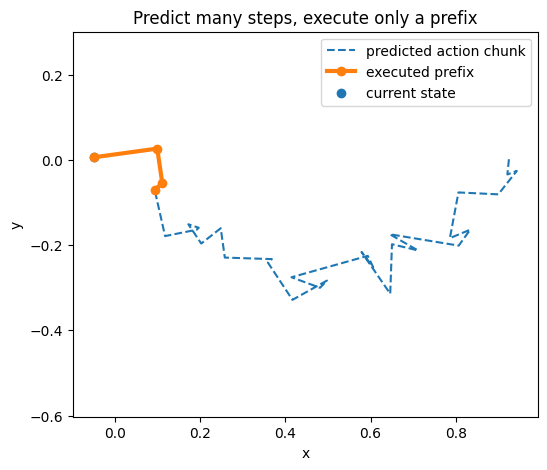

In [46]:
example_trajectory = recursive_samples[0]

executed_steps = 4

plt.figure(figsize=(6, 5))

plt.plot(
    example_trajectory[:, 0],
    example_trajectory[:, 1],
    linestyle="--",
    label="predicted action chunk",
)

plt.plot(
    example_trajectory[:executed_steps, 0],
    example_trajectory[:executed_steps, 1],
    marker="o",
    linewidth=3,
    label="executed prefix",
)

plt.scatter(
    example_trajectory[0, 0],
    example_trajectory[0, 1],
    label="current state",
)

plt.title("Predict many steps, execute only a prefix")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

## Is the Diffusion Generation Frequency Equal to the Robot Control Frequency?

No.

Suppose:

- diffusion generates one action chunk at a time;
- each chunk contains 16 actions;
- the low-level controller executes actions at 20 Hz;
- only the first 4 actions are executed from each chunk.

Then:

- the low-level action execution frequency remains 20 Hz;
- diffusion generates a new chunk every 4 control steps;
- the diffusion replanning frequency is approximately 5 Hz.

We must therefore distinguish among:

1. the frequency of complete model inference;
2. the execution frequency of actions within the action chunk;
3. the frequency of low-level position, impedance, or motor control.

A common hierarchy is closer to:

```text
Diffusion Policy: generates action chunks at low to medium frequency
        ↓
Position or impedance controller: tracks them at a higher frequency
        ↓
Motor servo: executes at an even higher frequency
```


## What Does Diffusion Policy Actually Solve?

Diffusion Policy is primarily used to model a conditional action distribution:

$$
p_\theta(A\mid O)
\approx
p_{\mathrm{demo}}(A\mid O)
$$

It is well suited for:

- generating continuous action chunks;
- modeling multimodal policy distributions;
- learning the global structure of demonstration trajectories;
- preventing ordinary regression from averaging multiple strategy modes into an infeasible compromise action.


## What Does Diffusion Policy Not Solve Automatically?

Generating a trajectory does not automatically turn Diffusion Policy into a complete robot planning and control system.

It does not automatically provide:

- collision constraints;
- guarantees of dynamic feasibility;
- proofs of control stability;
- high-frequency contact feedback;
- recovery from out-of-distribution failures;
- long-horizon task planning;
- motor-level control.

A more accurate description is:

> Diffusion Policy is a conditional action-trajectory generation model, not a complete robot control system.


# Final Summary

Training:

```text
Expert action A0
    ↓
Randomly choose noise level k
    ↓
Sample cumulative equivalent noise ε
    ↓
Directly construct Ak
    ↓
Learn: (Ak, k, condition O) → ε
```

Inference:

```text
Purely random action AK
    ↓
Predict cumulative noise at the current state
    ↓
Obtain a new intermediate action
    ↓
Predict again
    ↓
Recursively generate the final action chunk
```

The most important conclusions are:

1. The network predicts the cumulative equivalent noise in the current $A_k$ relative to a latent $A_0$, rather than single-step noise.
2. Because $A_0$ is known during training, exact supervision can be constructed for any $A_k$; this does not mean that the model learns to recover the actual $A_0$ in one step.
3. During inference, the denoising vector field must be queried repeatedly at continuously updated intermediate actions.
4. The main value of Diffusion Policy is its ability to generate continuous action chunks and model multimodal policy distributions.
5. A real robot usually executes only a prefix of an action chunk, while a higher-frequency low-level controller performs the tracking.
